In [82]:
# import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [4]:
# load data 
df = pd.read_excel(r"telecom_churn_analysis_raw.xlsx")

In [5]:
# check top 5 rows 
df.head()

,customer_id,name,gender,age,city,state,operator,customer_segment,interests,pincode
0,CUST1001,Customer_1,Male,39,Mumbai,Gujarat,Vi,Individual,Gaming,238099.0
1,CUST1002,Customer_2,Female,51,Chennai,Rajasthan,Vi,Business,Shopping,467904.0
2,CUST1003,Customer_3,Female,50,Lucknow,Maharashtra,Jio,Senior Citizen,NaN,856102.0
3,CUST1004,Customer_4,Male,41,Kolkata,Rajasthan,Airtel,Individual,Streaming,295865.0
4,CUST1005,Customer_5,Male,60,NaN,Uttar Pradesh,Airtel,Senior Citizen,Streaming,954227.0


In [6]:
# Check the number of rows and columns
df.shape

(120, 10)

In [8]:
#check columns names , data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       120 non-null    str    
 1   name              120 non-null    str    
 2   gender            112 non-null    str    
 3   age               120 non-null    int64  
 4   city              113 non-null    str    
 5   state             120 non-null    str    
 6   operator          120 non-null    str    
 7   customer_segment  120 non-null    str    
 8   interests         101 non-null    str    
 9   pincode           112 non-null    float64
dtypes: float64(1), int64(1), str(8)
memory usage: 9.5 KB


In [9]:
df.isnull().sum()

customer_id          0
name                 0
gender               8
age                  0
city                 7
state                0
operator             0
customer_segment     0
interests           19
pincode              8
dtype: int64

In [10]:
# check duplicates rows
df.duplicated().sum()

np.int64(0)

In [15]:
# Fill missing values with suitable values
df["gender"].value_counts()




gender
Female    68
Male      52
Name: count, dtype: int64

In [12]:
# Fill missing gender values with the most common gender
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])

In [13]:
df["gender"].isnull().sum()

np.int64(0)

In [16]:
# Check city frequency
df["city"].value_counts()

city
Bengaluru    18
Mumbai       17
Chennai      17
Jaipur       16
Lucknow      13
Delhi        12
Kolkata      11
Ahmedabad     9
Name: count, dtype: int64

In [17]:
# Fill missing interests with the most common interest
df["city"] = df["gender"].fillna(df["gender"].mode()[0])

In [22]:
df["pincode"].isnull().sum()

np.int64(0)

In [19]:
# Check pincode frequency
df["pincode"].value_counts()

pincode
238099.0    1
467904.0    1
856102.0    1
295865.0    1
954227.0    1
           ..
247376.0    1
740354.0    1
249316.0    1
475977.0    1
852673.0    1
Name: count, Length: 112, dtype: int64

In [20]:
df["pincode"] = df["pincode"].fillna(df["pincode"].mode()[0])

In [23]:
df["pincode"].isnull().sum()

np.int64(0)

In [24]:
#check duplicate rows
df.duplicated().sum()

np.int64(0)

In [25]:
# Check unique values in categorical columns
print(df["gender"].unique())
print(df["city"].unique())
print(df["operator"].unique())
print(df["customer_segment"].unique())
print(df["interests"].unique())

<StringArray>
['Male', 'Female']
Length: 2, dtype: str
<StringArray>
['Male', 'Female']
Length: 2, dtype: str
<StringArray>
['Vi', 'Jio', 'Airtel', 'jio', 'BSNL']
Length: 5, dtype: str
<StringArray>
['Individual', 'Business ', 'Senior Citizen', 'Business', 'Student']
Length: 5, dtype: str
<StringArray>
['Gaming', 'Shopping', nan, 'Streaming', 'Sports', 'Travel']
Length: 6, dtype: str


In [26]:
# Remove extra spaces and fix inconsistent operator values
df["operator"] = df["operator"].str.strip().str.title()
df["customer_segment"] = df["customer_segment"].str.strip()

# Fill missing interests with the most common interest
df["interests"] = df["interests"].fillna(df["interests"].mode()[0])

# Check the cleaned categorical values
print(df["operator"].unique())
print(df["customer_segment"].unique())
print(df["interests"].unique())

<StringArray>
['Vi', 'Jio', 'Airtel', 'Bsnl']
Length: 4, dtype: str
<StringArray>
['Individual', 'Business', 'Senior Citizen', 'Student']
Length: 4, dtype: str
<StringArray>
['Gaming', 'Shopping', 'Streaming', 'Sports', 'Travel']
Length: 5, dtype: str


In [27]:
# Check summary statistics of numeric columns
df[["age", "pincode"]].describe()

,age,pincode
count,120.000000,120.000000
mean,42.508333,517305.925000
std,13.505054,255671.124663
min,18.000000,109654.000000
25%,32.000000,301241.000000
50%,42.000000,541764.500000
75%,53.000000,732567.000000
max,67.000000,995917.000000


In [31]:
# Load the subscriptions
subscription = pd.read_excel("telecom_churn_analysis_raw.xlsx", sheet_name = "subscriptions_raw")

# Check the first five rows
subscription.head()


,customer_id,subscription_start_date,subscription_type,plan_type,contract_type,monthly_charges,tenure_months,cancellation_date,cancellation_reason,churn_status,churn_score
0,CUST1001,2023-01-26,Postpaid,standard,Monthly,1008.52,13,2025-01-22,No longer needed,Yes,40
1,CUST1002,2024-05-18,Prepaid,Premium,Monthly,1175.09,57,NaN,NaN,No,85
2,CUST1003,2022-04-19,Postpaid,Basic,Monthly,1230.73,70,NaN,NaN,No,58
3,CUST1004,2024-07-27,Prepaid,Standard,Monthly,474.54,24,NaN,NaN,No,10
4,CUST1005,2024-03-28,Postpaid,Basic,Quarterly,1399.92,36,NaN,NaN,No,30


In [32]:
# Check the number of rows and columns
subscription.shape

(120, 11)

In [33]:
subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              120 non-null    str    
 1   subscription_start_date  120 non-null    str    
 2   subscription_type        120 non-null    str    
 3   plan_type                120 non-null    str    
 4   contract_type            120 non-null    str    
 5   monthly_charges          113 non-null    float64
 6   tenure_months            120 non-null    int64  
 7   cancellation_date        37 non-null     str    
 8   cancellation_reason      36 non-null     str    
 9   churn_status             120 non-null    str    
 10  churn_score              120 non-null    int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 10.4 KB


In [34]:
subscription.isnull().sum()

customer_id                 0
subscription_start_date     0
subscription_type           0
plan_type                   0
contract_type               0
monthly_charges             7
tenure_months               0
cancellation_date          83
cancellation_reason        84
churn_status                0
churn_score                 0
dtype: int64

In [35]:
# Check duplicate subscription records
subscription.duplicated().sum()

np.int64(0)

In [36]:
# Check duplicate subscription records
subscription["monthly_charges"].describe()

count     113.000000
mean      884.685221
std       361.947570
min       208.760000
25%       592.220000
50%       889.840000
75%      1175.090000
max      1497.190000
Name: monthly_charges, dtype: float64

In [37]:
# Fill missing monthly charges with the median value
subscription["monthly_charges"] = subscription["monthly_charges"].fillna(subscription["monthly_charges"].median())

# verify missing values 
subscription["monthly_charges"].isnull().sum()

np.int64(0)

In [38]:
# Check unique values in subscription categories
print(subscription["subscription_type"].unique())
print(subscription["plan_type"].unique())
print(subscription["contract_type"].unique())

<StringArray>
['Postpaid', 'Prepaid', 'Pre-paid']
Length: 3, dtype: str
<StringArray>
['standard', 'Premium', 'Basic', 'Standard']
Length: 4, dtype: str
<StringArray>
['Monthly', 'Quarterly', 'Annual']
Length: 3, dtype: str


In [39]:
# Standardize subscription and plan type values
subscription["subscription_type"] = subscription["subscription_type"].str.replace("-", "" , regex = False)
subscription["plan_type"] = subscription["plan_type"].str.title()

# Check the cleaned values
print(subscription["subscription_type"].unique())
print(subscription["plan_type"].unique())

<StringArray>
['Postpaid', 'Prepaid']
Length: 2, dtype: str
<StringArray>
['Standard', 'Premium', 'Basic']
Length: 3, dtype: str


In [40]:
# Check churn status values and their counts
subscription["churn_status"].value_counts()

churn_status
No     83
Yes    37
Name: count, dtype: int64

In [41]:
# Compare cancellation data with churn status
pd.crosstab(subscription["churn_status"], subscription["cancellation_date"].isnull())

cancellation_date,False,True
churn_status,,
No,0,83
Yes,37,0


In [43]:
# Check cancellation reason against churn status
pd.crosstab(subscription["churn_status"], subscription["cancellation_reason"].isnull())

cancellation_reason,False,True
churn_status,,
No,0,83
Yes,36,1


In [44]:
# Check cancellation reasons for churned customers
subscription.loc[subscription["churn_status"] == "Yes", "cancellation_reason"].value_counts()


cancellation_reason
High charges              12
No longer needed          11
Customer service           7
Switched to competitor     4
Poor network               2
Name: count, dtype: int64

In [45]:
# Fill the missing cancellation reason with the most common reason
subscription["cancellation_reason"] = subscription["cancellation_reason"].fillna(
    subscription.loc[subscription["churn_status"] == "Yes", "cancellation_reason"].mode()[0]
)

# Verify missing values
subscription["cancellation_reason"].isnull().sum()

np.int64(0)

In [46]:
# Check duplicate subscription records
subscription.duplicated().sum()

np.int64(0)

In [47]:
# Convert date columns to datetime format
subscription["subscription_start_date"] = pd.to_datetime(
    subscription["subscription_start_date"]
)

subscription["cancellation_date"] = pd.to_datetime(
    subscription["cancellation_date"]
)

# Check the converted data types
subscription[["subscription_start_date", "cancellation_date"]].dtypes

subscription_start_date    datetime64[us]
cancellation_date          datetime64[us]
dtype: object

In [48]:
# Check numerical columns for invalid values
subscription[["tenure_months", "churn_score"]].describe()

,tenure_months,churn_score
count,120.000000,120.000000
mean,38.983333,51.733333
std,20.655633,27.908233
min,1.000000,7.000000
25%,24.000000,25.750000
50%,38.000000,50.500000
75%,57.000000,75.000000
max,71.000000,99.000000


In [49]:
# Check missing values after cleaning
subscription.isnull().sum()


customer_id                 0
subscription_start_date     0
subscription_type           0
plan_type                   0
contract_type               0
monthly_charges             0
tenure_months               0
cancellation_date          83
cancellation_reason         0
churn_status                0
churn_score                 0
dtype: int64

In [50]:
# Load the customer support data
support = pd.read_excel(r"telecom_churn_analysis_raw.xlsx", sheet_name = "support_raw")

#check the first five rows
support.head()

#check rows , colums and missing values
support.shape
support.info()
support.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        150 non-null    str           
 1   complaint_date     150 non-null    datetime64[us]
 2   complaint_type     150 non-null    str           
 3   escalations        150 non-null    str           
 4   csat_score         140 non-null    float64       
 5   resolution_status  150 non-null    str           
 6   comment            125 non-null    str           
dtypes: datetime64[us](1), float64(1), str(5)
memory usage: 8.3 KB


customer_id           0
complaint_date        0
complaint_type        0
escalations           0
csat_score           10
resolution_status     0
comment              25
dtype: int64

In [51]:
# check csat score statistics
support["csat_score"].describe()

count    140.000000
mean      53.528571
std       27.469392
min        1.000000
25%       30.750000
50%       53.500000
75%       76.000000
max      100.000000
Name: csat_score, dtype: float64

In [52]:
# fill missing Csat scores with the missing score
support["csat_score"] = support["csat_score"].fillna(support["csat_score"].median())

# verify missing values
support["csat_score"].isnull().sum()

np.int64(0)

In [53]:
# Fill missing comments with a standard value
support["comment"] = support["comment"].fillna("No comment")

# verify missing values
support["comment"].isnull().sum()

np.int64(0)

In [54]:
# check unique values in support categories
print(support["complaint_type"].unique())
print(support["escalations"].unique())
print(support["resolution_status"].unique())

<StringArray>
[    'Recharge',     'Internet',      'Network',        'Other',
      'network', 'Call Quality',      'Billing']
Length: 7, dtype: str
<StringArray>
['N', 'Y']
Length: 2, dtype: str
<StringArray>
['Resolved', 'Escalated', 'Pending', 'resolved']
Length: 4, dtype: str


In [56]:
# Standardize support category values
support["complaint_type"] = support["complaint_type"].str.title()
support["resolution_status"] = support["resolution_status"].str.title()

#check cleaned values
print(support["complaint_type"].unique())
print(support["resolution_status"].unique())

<StringArray>
['Recharge', 'Internet', 'Network', 'Other', 'Call Quality', 'Billing']
Length: 6, dtype: str
<StringArray>
['Resolved', 'Escalated', 'Pending']
Length: 3, dtype: str


In [57]:
# Check duplicate support records
support.duplicated().sum()

# Check CSAT score range
support["csat_score"].describe()

# Check remaining missing values
support.isnull().sum()

customer_id          0
complaint_date       0
complaint_type       0
escalations          0
csat_score           0
resolution_status    0
comment              0
dtype: int64

In [58]:
# Check duplicate support records
support.duplicated().sum()


np.int64(0)

In [59]:
# Merge customer and subscription data using customer_id
churn_df = pd.merge(df, subscription, on = "customer_id", how = "inner")

#check the merged dataset
churn_df.shape

(120, 20)

In [62]:
# Calculate the overall churn rate
churn_rate = (churn_df["churn_status"] == "Yes" ).mean()*100

print(f"Overall Churn Rate: {churn_rate:2f}%")

Overall Churn Rate: 30.833333%


In [63]:
# Count customers by churn status
churn_df["churn_status"].value_counts()

churn_status
No     83
Yes    37
Name: count, dtype: int64

In [64]:
# Check all cleaned sheets

print("CUSTOMERS")
print(df.shape)
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

print("\nSUBSCRIPTIONS")
print(subscription.shape)
print(subscription.isnull().sum())
print("Duplicates:", subscription.duplicated().sum())

print("\nSUPPORT")
print(support.shape)
print(support.isnull().sum())
print("Duplicates:", support.duplicated().sum())

CUSTOMERS
(120, 10)
customer_id         0
name                0
gender              0
age                 0
city                0
state               0
operator            0
customer_segment    0
interests           0
pincode             0
dtype: int64
Duplicates: 0

SUBSCRIPTIONS
(120, 11)
customer_id                 0
subscription_start_date     0
subscription_type           0
plan_type                   0
contract_type               0
monthly_charges             0
tenure_months               0
cancellation_date          83
cancellation_reason         0
churn_status                0
churn_score                 0
dtype: int64
Duplicates: 0

SUPPORT
(150, 7)
customer_id          0
complaint_date       0
complaint_type       0
escalations          0
csat_score           0
resolution_status    0
comment              0
dtype: int64
Duplicates: 0


In [65]:
# Check the basic statistics of customer and subscription data
print(churn_df[["age", "monthly_charges", "tenure_months", "churn_score"]].describe())

              age  monthly_charges  tenure_months  churn_score
count  120.000000       120.000000     120.000000   120.000000
mean    42.508333       884.985917      38.983333    51.733333
std     13.505054       351.142816      20.655633    27.908233
min     18.000000       208.760000       1.000000     7.000000
25%     32.000000       615.205000      24.000000    25.750000
50%     42.000000       889.840000      38.000000    50.500000
75%     53.000000      1168.992500      57.000000    75.000000
max     67.000000      1497.190000      71.000000    99.000000


In [66]:
# Check customer and subscription category distribution
print(churn_df["operator"].value_counts())
print(churn_df["subscription_type"].value_counts())
print(churn_df["plan_type"].value_counts())
print(churn_df["contract_type"].value_counts())
print(churn_df["customer_segment"].value_counts())

operator
Jio       47
Airtel    37
Vi        27
Bsnl       9
Name: count, dtype: int64
subscription_type
Prepaid     83
Postpaid    37
Name: count, dtype: int64
plan_type
Standard    53
Basic       44
Premium     23
Name: count, dtype: int64
contract_type
Monthly      58
Annual       37
Quarterly    25
Name: count, dtype: int64
customer_segment
Individual        32
Business          32
Senior Citizen    32
Student           24
Name: count, dtype: int64


In [67]:
# Standardize operator names
churn_df["operator"] = churn_df["operator"].replace({"Bsnl": "BSNL"})

# Verify operator values
churn_df["operator"].value_counts()



operator
Jio       47
Airtel    37
Vi        27
BSNL       9
Name: count, dtype: int64

In [68]:
# Calculate churn rate for each operator
operator_churn = pd.crosstab(
    churn_df["operator"],
    churn_df["churn_status"],
    normalize="index"
) * 100

operator_churn

churn_status,No,Yes
operator,,
Airtel,72.972973,27.027027
BSNL,100.000000,0.000000
Jio,55.319149,44.680851
Vi,77.777778,22.222222


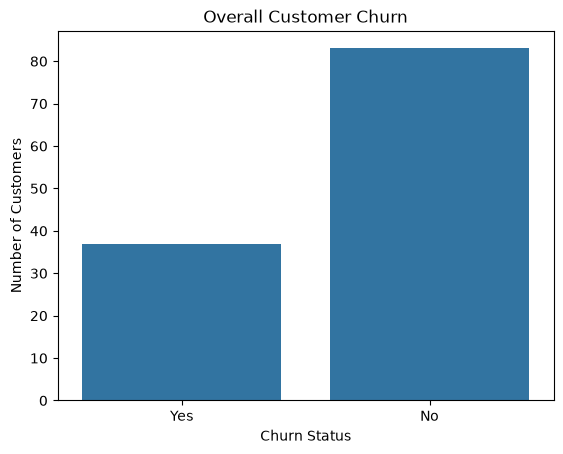

In [69]:
# Visualize overall customer churn
sns.countplot(data = churn_df, x = "churn_status")
plt.title("Overall Customer Churn")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.show()

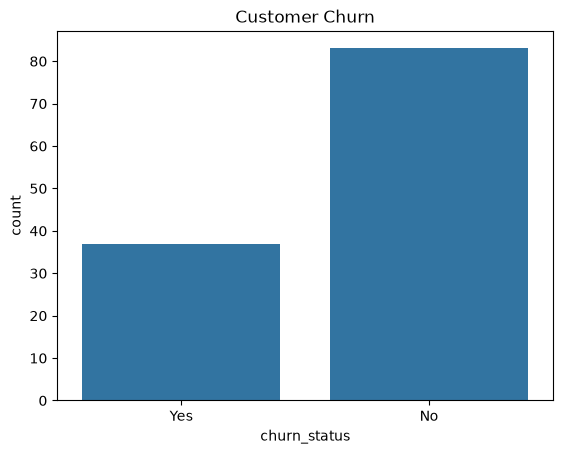

In [70]:
# Visualize overall churn
sns.countplot(data=churn_df, x="churn_status")
plt.title("Customer Churn")
plt.show()

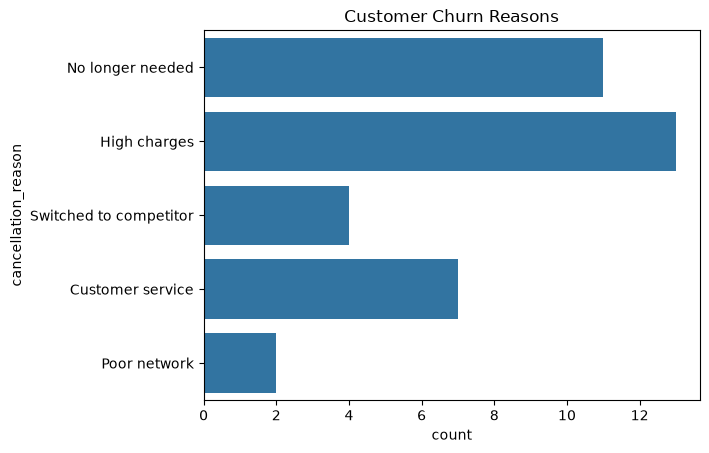

In [71]:
# Visualize reasons for customer churn
sns.countplot(
    data = churn_df[churn_df["churn_status"]== "Yes"],
    y = "cancellation_reason"
)

plt.title("Customer Churn Reasons")
plt.show()

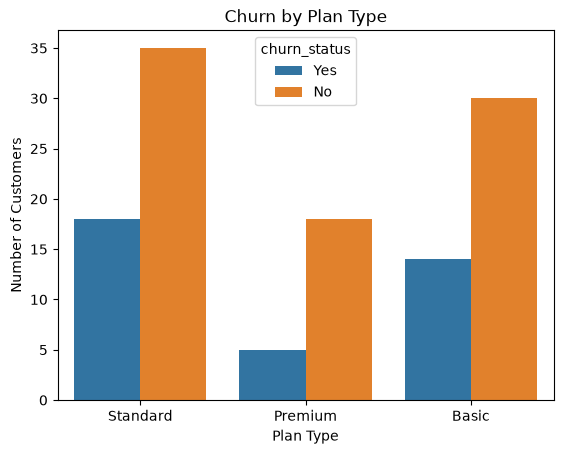

In [78]:
# Visualize churn by plan type
sns.countplot(
    data = churn_df,
    x = "plan_type",
    hue = "churn_status"
)

plt.title("Churn by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Number of Customers")
plt.show()

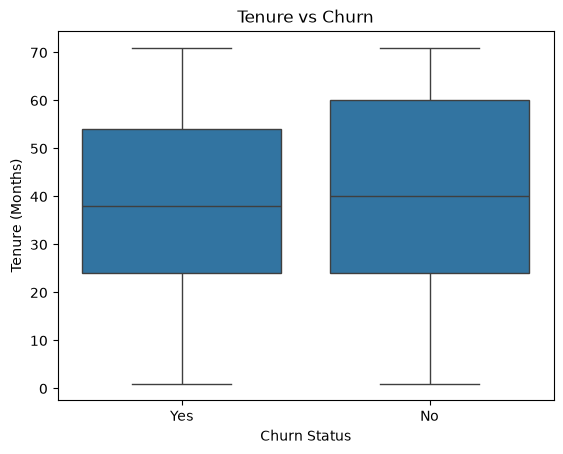

In [79]:
# Compare customer tenure with churn status
sns.boxplot(
    data = churn_df,
    x = "churn_status",
    y = "tenure_months"
)
plt.title("Tenure vs Churn")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")
plt.show()

In [80]:
# Save the merged churn data as CSV
churn_df.to_csv("telecom_churn_cleaned.csv", index = False)

In [84]:
conn = sqlite3.connect("telecom_churn.db")


In [85]:
# Load cleaned CSV into SQL table
churn_df.to_sql("churn_data", conn, if_exists="replace", index=False)

120

In [86]:
# Run SQL query for total customers
query = """
SELECT COUNT(*) AS total_customers
FROM churn_data;
"""

result = pd.read_sql_query(query, conn)
result

,total_customers
0,120


In [87]:
# Find the number of churned customers
query = """ 
SELECT COUNT(*) AS churned_customers
FROM churn_data
WHERE churn_status = 'Yes';
"""
result = pd.read_sql_query(query, conn)
result

,churned_customers
0,37


In [89]:
# Calculate overall churn rate
query = """
SELECT 
    ROUND(
        100.0 * SUM(CASE WHEN churn_status = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM churn_data;
"""

result = pd.read_sql_query(query, conn)
result

,churn_rate
0,30.83


In [90]:
# Calculate churn rate for each operator
query = """
SELECT
    operator,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN churn_status = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN churn_status = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM churn_data
GROUP BY operator
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)
result

,operator,total_customers,churned_customers,churn_rate
0,Jio,47,21,44.68
1,Airtel,37,10,27.03
2,Vi,27,6,22.22
3,BSNL,9,0,0.00


In [91]:
# Calculate churn rate for each plan
query = """
SELECT
    plan_type,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN churn_status = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN churn_status = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM churn_data
GROUP BY plan_type
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)
result

,plan_type,total_customers,churned_customers,churn_rate
0,Standard,53,18,33.96
1,Basic,44,14,31.82
2,Premium,23,5,21.74


In [92]:
# Count customers by churn reason
query = """
SELECT
    cancellation_reason,
    COUNT(*) AS churned_customers
FROM churn_data
WHERE churn_status = 'Yes'
GROUP BY cancellation_reason
ORDER BY churned_customers DESC;
"""

result = pd.read_sql_query(query, conn)
result

,cancellation_reason,churned_customers
0,High charges,13
1,No longer needed,11
2,Customer service,7
3,Switched to competitor,4
4,Poor network,2
